# E-Commerce Customer Lifecycle & Churn Prevention Analysis
**Author:** Data Science Intern, The Developers Arena  
**Domain:** Retail Analytics & Machine Learning Lifecycle Management  
**Dataset:** 1,200 Customer Account Profiles (20 Behavioral Features)

### Objective:
1. Diagnose root causes of customer churn.
2. Train and evaluate predictive classification models (Random Forest, Logistic Regression).
3. Segment at-risk cohorts via K-Means clustering.
4. Provide data-driven business recommendations and operational rollout schedules.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')


Libraries imported successfully.


## Phase 2: Data Ingestion & Quality Control
- Assess null values, column datatypes, and distributions.
- Impute missing records using median logic.
- Treat extreme outliers via 99th-percentile Winsorization.


In [2]:
raw_df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\WEEKS 8\data\raw_data.csv')
print('Raw Dataset Dimensions:', raw_df.shape)
print('\nMissing Value Summary:\n', raw_df.isnull().sum()[raw_df.isnull().sum() > 0])

# Imputation & Cleaning
df = raw_df.copy()
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
df['DaySinceLastOrder'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median())

# 99th-percentile Winsorization
for col in ['WarehouseToHome', 'DaySinceLastOrder']:
    p99 = df[col].quantile(0.99)
    df[col] = np.where(df[col] > p99, p99, df[col])

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'COD': 'Cash on Delivery'})
df.to_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\WEEKS 8\data\cleaned_data.csv', index=False)
print('Cleaned dataset saved. Remaining nulls:', df.isnull().sum().sum())


Raw Dataset Dimensions: (1200, 20)

Missing Value Summary:
 Tenure               25
DaySinceLastOrder    30
dtype: int64
Cleaned dataset saved. Remaining nulls: 0


## Phase 3: Exploratory Data Analysis & Diagnostic Visualizations
We evaluate churn concentrations across customer tenure, complaint registrations, satisfaction scores, and dormancy recency.


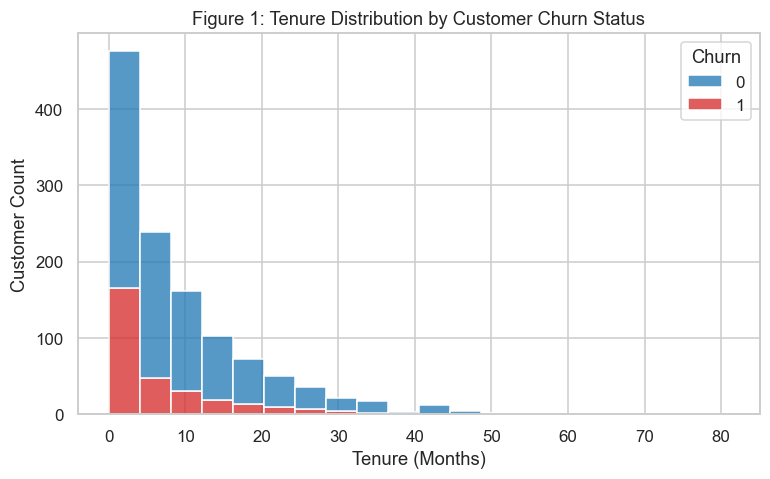

In [4]:
# 1. Tenure vs Churn Histogram
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df, x='Tenure', hue='Churn', bins=20, multiple='stack', palette=['#1f77b4', '#d62728'])
plt.title('Figure 1: Tenure Distribution by Customer Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')
plt.show()

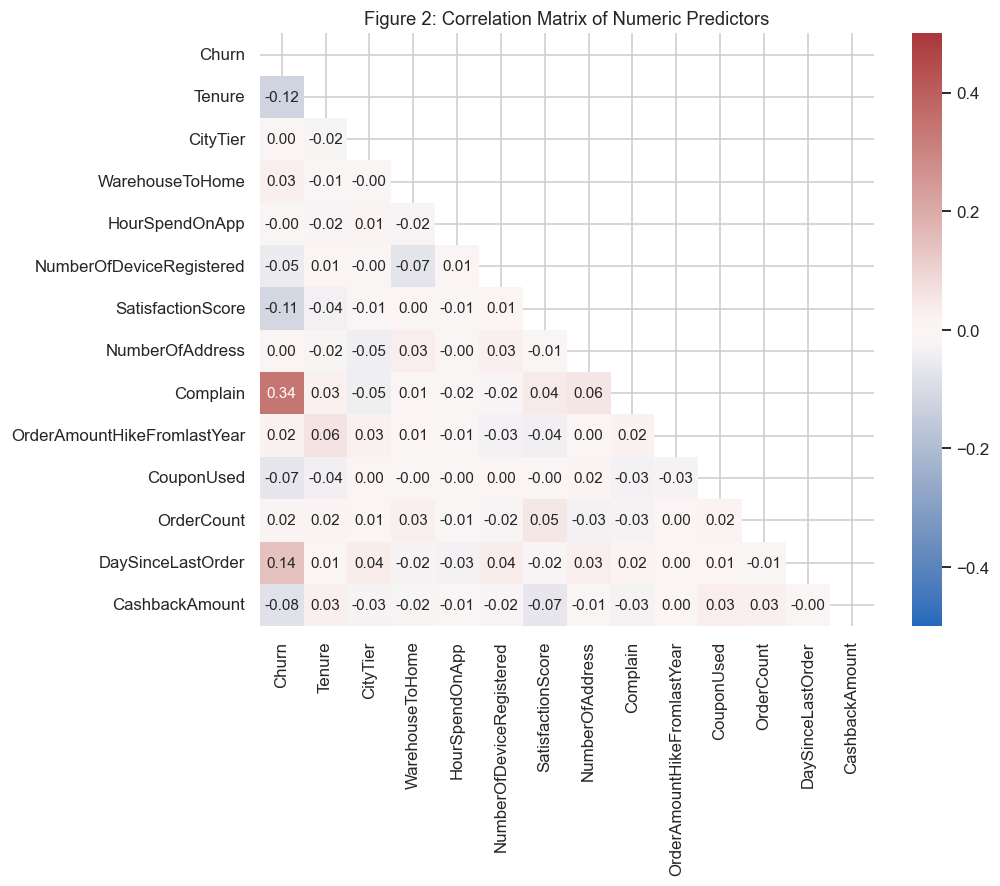

In [5]:
# 2. Correlation Matrix
plt.figure(figsize=(9, 7))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='vlag', vmin=-0.5, vmax=0.5)
plt.title('Figure 2: Correlation Matrix of Numeric Predictors')
plt.show()

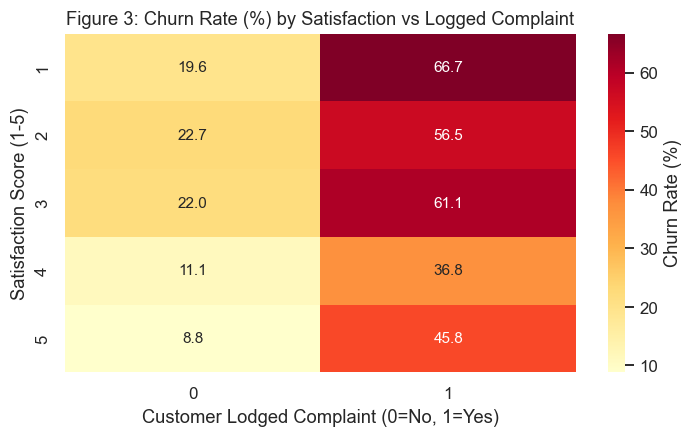

In [6]:
# 3. Satisfaction Score vs Complaints Heatmap
plt.figure(figsize=(7.5, 4))
churn_sat = df.groupby(['SatisfactionScore', 'Complain'])['Churn'].mean().unstack() * 100
sns.heatmap(churn_sat, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Figure 3: Churn Rate (%) by Satisfaction vs Logged Complaint')
plt.xlabel('Customer Lodged Complaint (0=No, 1=Yes)')
plt.ylabel('Satisfaction Score (1-5)')
plt.show()

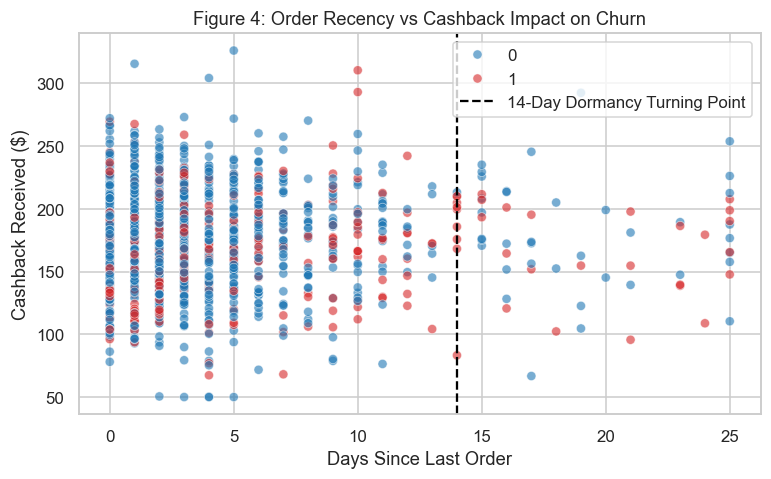

In [7]:
# 4. Inactivity Recency vs Cashback Threshold
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df, x='DaySinceLastOrder', y='CashbackAmount', hue='Churn', alpha=0.6, palette=['#1f77b4', '#d62728'])
plt.axvline(x=14, color='black', linestyle='--', label='14-Day Dormancy Turning Point')
plt.title('Figure 4: Order Recency vs Cashback Impact on Churn')
plt.xlabel('Days Since Last Order')
plt.ylabel('Cashback Received ($)')
plt.legend()
plt.show()

## Phase 4: Advanced Statistical Inference & Predictive Machine Learning
Implementing:  
1. **Econometric Logistic Regression** (`statsmodels`) to calculate odds ratios.  
2. **Supervised Random Forest Classifier** (`scikit-learn`) for risk probability scoring.  
3. **Unsupervised K-Means Behavioral Clustering** for audience segmentation.


--- Technique 1: Top Significant Odds Ratios (p < 0.05) ---
                       Odds Ratio       P-Value
Complain                 7.524591  3.455258e-26
MaritalStatus_Married    1.752862  4.431232e-02
OrderCount               1.112994  3.660666e-02
DaySinceLastOrder        1.076033  1.069565e-05
Tenure                   0.949602  2.339274e-06

--- Technique 2: Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.97      0.86       224
           1       0.67      0.18      0.29        76

    accuracy                           0.77       300
   macro avg       0.72      0.58      0.58       300
weighted avg       0.75      0.77      0.72       300

Test Area Under ROC Curve (ROC-AUC): 0.7605


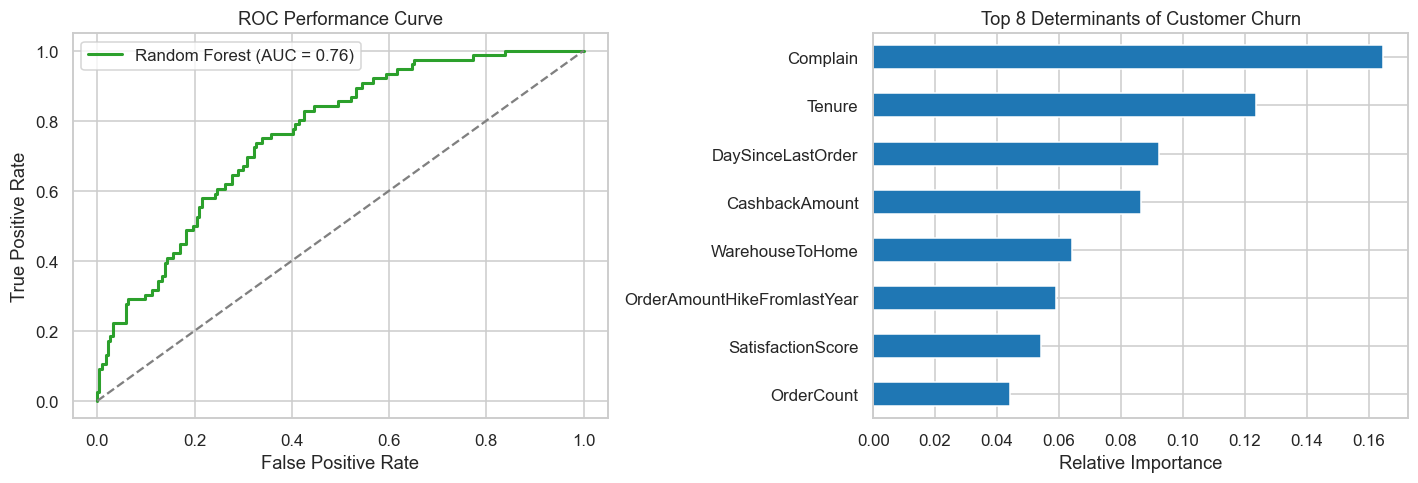

In [8]:
# One-hot encoding of categorical features
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
df_encoded = pd.get_dummies(df.drop(columns=['CustomerID']), columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Technique 1: Logistic Regression Odds Ratios
X_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_sm.astype(float)).fit(disp=False)
odds_df = pd.DataFrame({'Odds Ratio': np.exp(logit_model.params), 'P-Value': logit_model.pvalues})
print('--- Technique 1: Top Significant Odds Ratios (p < 0.05) ---')
print(odds_df[odds_df['P-Value'] < 0.05].sort_values(by='Odds Ratio', ascending=False).head(5))

# Technique 2: Random Forest Classification
rf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)

print('\n--- Technique 2: Random Forest Classification Report ---')
print(classification_report(y_test, y_pred))
print(f'Test Area Under ROC Curve (ROC-AUC): {auc_score:.4f}')

# Visualizing ROC Curve and Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#2ca02c', lw=2, label=f'Random Forest (AUC = {auc_score:.2f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('ROC Performance Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

feat_importances = pd.Series(rf.feature_importances_, index=X.columns).nlargest(8)
feat_importances.sort_values().plot(kind='barh', ax=axes[1], color='#1f77b4')
axes[1].set_title('Top 8 Determinants of Customer Churn')
axes[1].set_xlabel('Relative Importance')
plt.tight_layout()
plt.show()


## Technique 3: Unsupervised K-Means Customer Segmentation
Segmenting customers by standardized Tenure, Order Count, Recency, and Cashback parameters.


In [9]:
rfm_features = df[['Tenure', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(scaled_features)

cluster_summary = df.groupby('Segment').agg({
    'Tenure': 'mean',
    'OrderCount': 'mean',
    'DaySinceLastOrder': 'mean',
    'CashbackAmount': 'mean',
    'Churn': 'mean'
}).rename(columns={'Churn': 'Churn Rate'})
cluster_summary['Churn Rate'] = (cluster_summary['Churn Rate'] * 100).round(1).astype(str) + '%'
print('--- Technique 3: Customer Clusters Behavioral Summary ---')
print(cluster_summary)


--- Technique 3: Customer Clusters Behavioral Summary ---
            Tenure  OrderCount  DaySinceLastOrder  CashbackAmount Churn Rate
Segment                                                                     
0         5.429287    3.116395           2.555695      174.531377      24.4%
1        25.581498    3.215859           3.409692      178.713524      14.5%
2         7.126437    2.908046          13.672414      174.158736      43.1%


C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
